# Implementasi Naive Bayes (GaussianNB) dengan Python & KNIME



## 1. Pengertian Naive Bayes

Naive Bayes adalah algoritma klasifikasi berbasis probabilitas yang menggunakan Teorema Bayes untuk menentukan kemungkinan suatu data termasuk ke dalam kelas tertentu berdasarkan nilai fitur yang dimiliki.

Algoritma ini menghitung probabilitas setiap kelas, kemudian memilih kelas dengan probabilitas terbesar sebagai hasil prediksi.


**Rumus Naive Bayes**

Rumus utama:

P(C|X) = (P(X|C) * P(C)) / P(X)

Keterangan:
- C = kelas (misalnya Outcome: 0 atau 1)
- X = data fitur (age, chol, dll)
- P(C|X) = probabilitas data X termasuk kelas C
- P(C) = probabilitas awal (prior)
- P(X|C) = likelihood (kemungkinan data muncul pada kelas C)
- P(X) = evidence


## 2. Implementasi Menggunakan Python



In [10]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

Penjelasan:
* pandas → untuk membaca dan mengolah data CSV
* train_test_split → membagi data training & testing
* GaussianNB → model Naive Bayes untuk data numerik
* accuracy_score → menghitung akurasi model
* confusion_matrix → melihat hasil klasifikasi
* classification_report → laporan lengkap (precision, recall, f1-score)

In [11]:
from google.colab import files
uploaded = files.upload()

file_name = list(uploaded.keys())[0]

Saving diabetes.csv to diabetes (1).csv


* files.upload() → membuka tombol upload file
* File yang kamu pilih akan masuk ke Colab
* uploaded.keys() → mengambil nama file
* [0] → karena biasanya cuma upload 1 file

In [12]:
data = pd.read_csv(file_name)

print(data.head())

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  


* read_csv() → membaca file CSV jadi tabel
* data.head() → menampilkan 5 baris pertama
Digunakan untuk memastikan data sudah terbaca dengan benar

In [13]:
X = data.drop("Outcome", axis=1)
y = data["Outcome"]

Penjelasan:
* X → fitur (input model)
* y → label (target yang diprediksi)

Kolom Outcome:

* 0 = tidak diabetes
* 1 = diabetes
* drop("Outcome") → menghapus kolom target dari fitur

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Penjelasan:
* Data dibagi jadi:
- 80% training
- 20% testing
* random_state=42 → supaya hasil konsisten setiap dijalankan

In [ ]:
model = GaussianNB()
model.fit(X_train, y_train)

Penjelasan:
GaussianNB() → membuat model Naive Bayes
fit() → melatih model menggunakan data training


In [16]:
y_pred = model.predict(X_test)

Penjelasan:
* Model digunakan untuk memprediksi data baru (testing)
* Hasilnya disimpan di y_pred

In [17]:
print("Akurasi:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Akurasi: 0.7662337662337663
Confusion Matrix:
 [[79 20]
 [16 39]]
Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.80      0.81        99
           1       0.66      0.71      0.68        55

    accuracy                           0.77       154
   macro avg       0.75      0.75      0.75       154
weighted avg       0.77      0.77      0.77       154



Penjelasan:

* Accuracy
- Persentase prediksi yang benar

* Confusion Matrix
- TN = benar tidak diabetes
- TP = benar diabetes
- FP = salah prediksi diabetes
- FN = salah prediksi tidak diabetes

* Classification Report


- Precision
- Recall
- F1-score

## 3. Implementasi Menggunakan KNIME


Alur Kerja Workflow

Pembaca CSV → Skrip Python → Tabel view

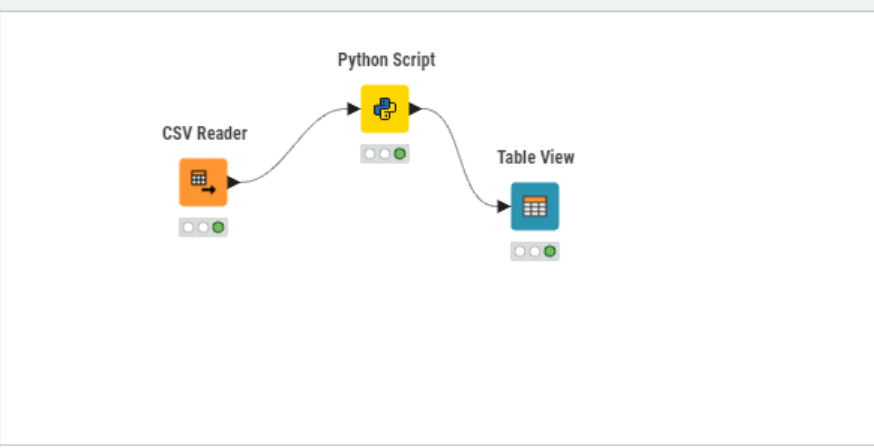

---


1. CSV Reader
Node ini digunakan untuk membaca dataset dari file CSV ke dalam KNIME.

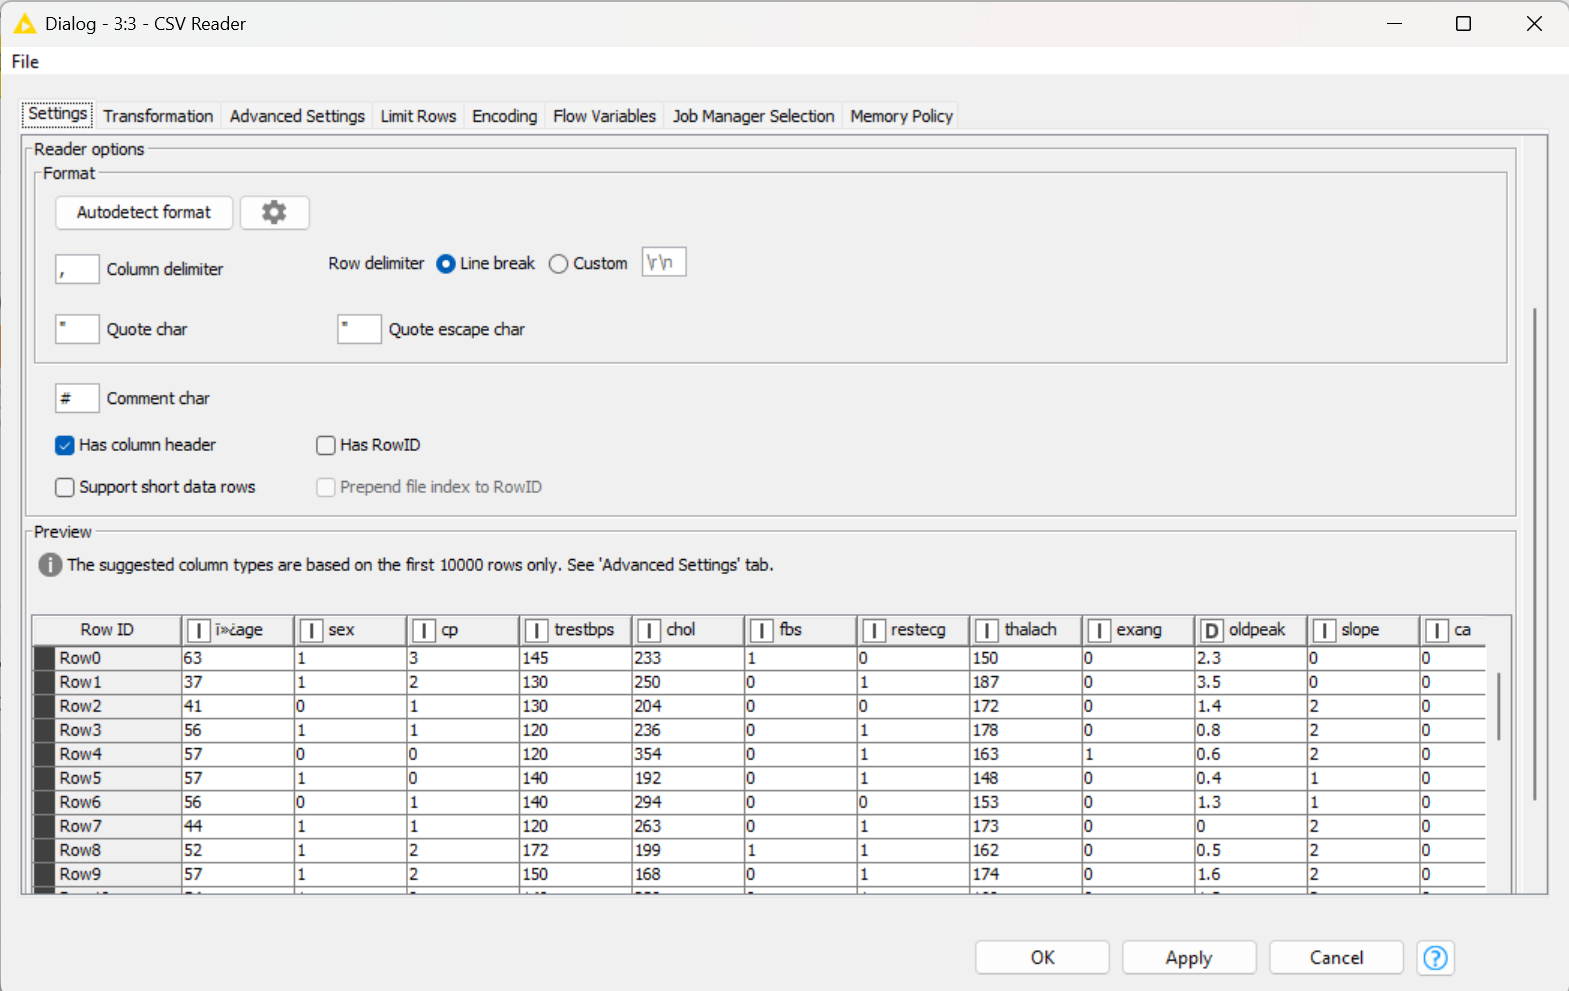

2. Python Script


```python
import knime.scripting.io as knio
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix

# Ambil data dari KNIME
df = knio.input_tables[0].to_pandas()

# Pisahkan fitur dan target
X = df.drop(columns=["Outcome"])
y = df["Outcome"]

# Split data (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Training model
model = GaussianNB()
model.fit(X_train, y_train)

# Prediksi
y_pred = model.predict(X_test)

# Evaluasi
acc = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

# Ambil nilai confusion matrix
tn, fp, fn, tp = cm.ravel()

# Output ke KNIME
output = pd.DataFrame({
    "Accuracy": [acc],
    "TN": [tn],
    "FP": [fp],
    "FN": [fn],
    "TP": [tp]
})

knio.output_tables[0] = knio.Table.from_pandas(output)





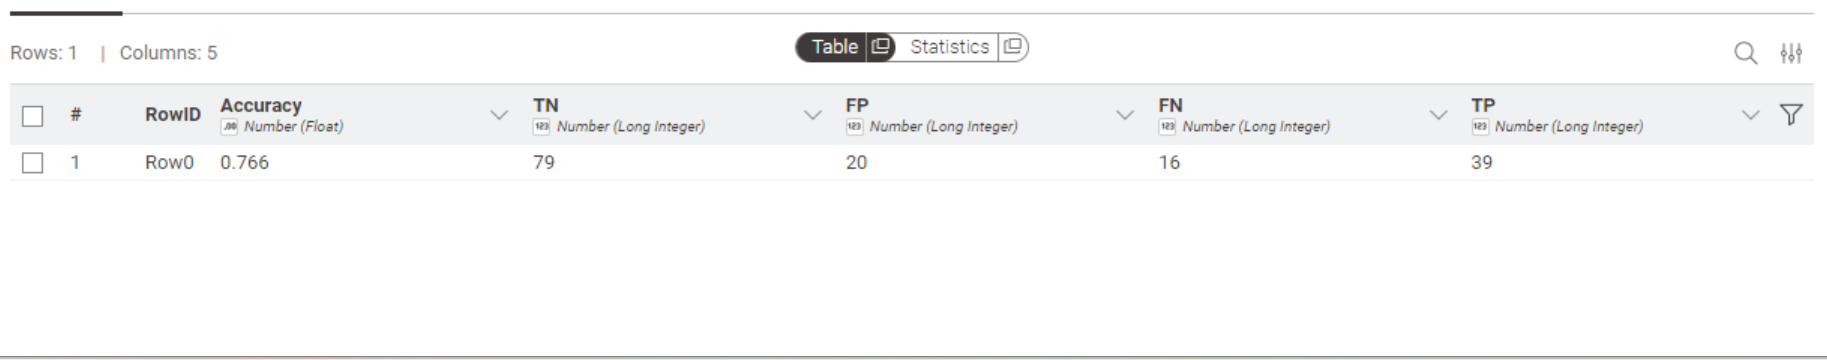


3. Table View


Node Table View berfungsi untuk:
- Menampilkan hasil evaluasi model dari Python Script
- Mempermudah pengguna membaca hasil tanpa perlu membuka file tambahan


Node ini menerima input dari:
- Python Script Node

Data yang diterima berupa tabel hasil evaluasi, seperti:
- Accuracy
- TN (True Negative)
- FP (False Positive)
- FN (False Negative)
- TP (True Positive)

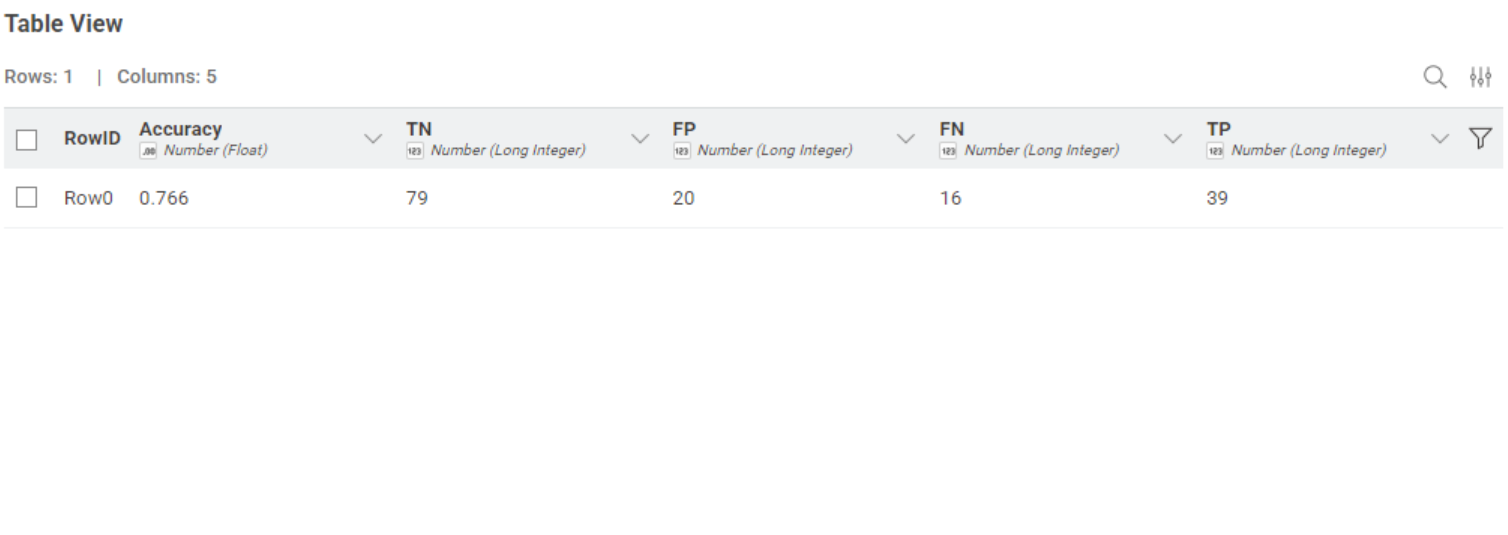